# End-to-End EDA for MSME Financial Health Card
This notebook performs exploratory data analysis, data cleaning, missing value imputation, VIF score calculation, heteroscedasticity checks, correlation analysis, and interaction feature creation.

In [ ]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as ss
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')

In [2]:
# Load the dataset
df = pd.read_csv('msme_synthetic_50k.csv')
print(f"Dataset shape: {df.shape}")

Dataset shape: (50000, 45)


# View of the Data

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 45 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   MSME_ID                         50000 non-null  object 
 1   Customer_Segment                50000 non-null  object 
 2   Business_Type                   50000 non-null  object 
 3   Industry                        50000 non-null  object 
 4   Location_Category               50000 non-null  object 
 5   Years_in_Operation              50000 non-null  float64
 6   Employee_Count                  50000 non-null  int64  
 7   Annual_Turnover_INR             50000 non-null  int64  
 8   Monthly_GST_Sales_INR           50000 non-null  int64  
 9   Monthly_GST_Purchases_INR       50000 non-null  int64  
 10  GST_Filing_Timeliness_Pct       50000 non-null  float64
 11  GST_Return_Frequency            50000 non-null  object 
 12  Monthly_UPI_Inflow_INR          

## 1. Data Cleaning & Missing Values Fill Strategies
We will inspect the missing values and apply appropriate imputation strategies (e.g., median for skewed continuous variables, mode for categorical).

In [4]:
# Check missing values
missing_df = df.isnull().sum().to_frame('Missing_Count')
missing_df['Missing_Pct'] = (missing_df['Missing_Count'] / len(df)) * 100
print(missing_df[missing_df['Missing_Count'] > 0])

# Fill missing values strategy
# Example: Monthly_Loan_EMI_INR might be missing for NTC/NTB without loans. Fill with 0.
if 'Monthly_Loan_EMI_INR' in df.columns:
    df['Monthly_Loan_EMI_INR'].fillna(0, inplace=True)

# For other numerical features, we can use the median
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

# For categorical features, fill with mode
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

# NOTE: If I would have more time, I would have analyzed the data and created an imputer to fill in the missing values

                      Missing_Count  Missing_Pct
EMI_On_Time_Rate_Pct          32556       65.112


# Visualize the Distribution of numerical and categorical data

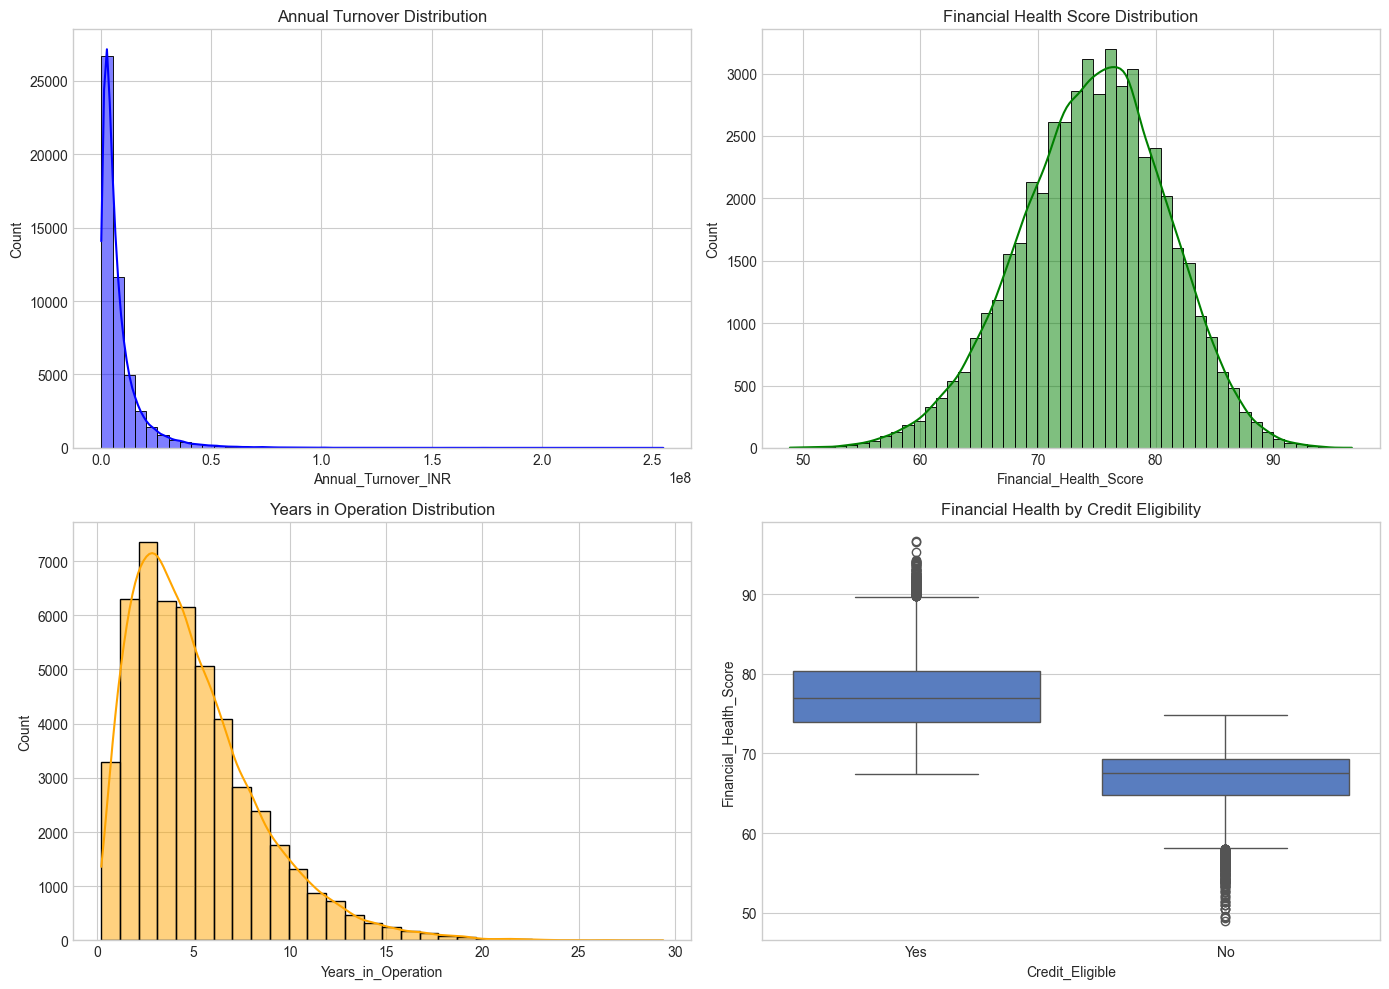

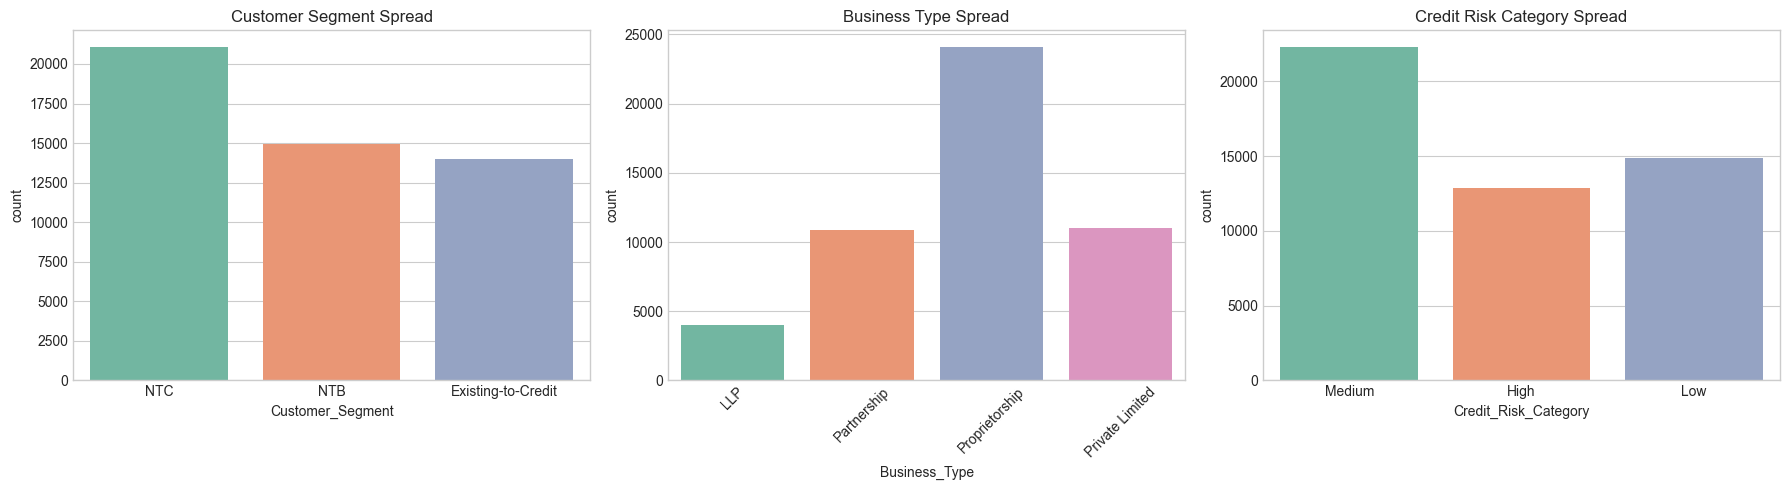

In [5]:
# Numerical features distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.histplot(df['Annual_Turnover_INR'], bins=50, kde=True, ax=axes[0,0], color='blue')
axes[0,0].set_title('Annual Turnover Distribution')

sns.histplot(df['Financial_Health_Score'], bins=50, kde=True, ax=axes[0,1], color='green')
axes[0,1].set_title('Financial Health Score Distribution')

sns.histplot(df['Years_in_Operation'], bins=30, kde=True, ax=axes[1,0], color='orange')
axes[1,0].set_title('Years in Operation Distribution')

sns.boxplot(x=df['Credit_Eligible'], y=df['Financial_Health_Score'], ax=axes[1,1])
axes[1,1].set_title('Financial Health by Credit Eligibility')

plt.tight_layout()
plt.show()

# Categorical data spread
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.countplot(x='Customer_Segment', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Customer Segment Spread')

sns.countplot(x='Business_Type', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('Business Type Spread')
axes[1].tick_params(axis='x', rotation=45)

sns.countplot(x='Credit_Risk_Category', data=df, ax=axes[2], palette='Set2')
axes[2].set_title('Credit Risk Category Spread')

plt.tight_layout()
plt.show()


## 2. Feature Engineering & Interaction Features
Creating new interaction features that make financial sense for MSMEs.

In [6]:
# Interaction 1: Turnover per Employee
df['Turnover_per_Employee'] = df['Annual_Turnover_INR'] / (df['Employee_Count'] + 1)

# Interaction 2: GST Sales to Purchases Ratio
df['GST_Sales_to_Purchases'] = df['Monthly_GST_Sales_INR'] / (df['Monthly_GST_Purchases_INR'] + 1)

# Interaction 3: UPI Dependency (UPI Inflow / Total Bank Credits)
df['UPI_Dependency'] = df['Monthly_UPI_Inflow_INR'] / (df['Monthly_Bank_Credits_INR'] + 1)

# Interaction 4: Credit to Debit Ratio
df['Credit_to_Debit_Ratio'] = df['Monthly_Bank_Credits_INR'] / (df['Monthly_Bank_Debits_INR'] + 1)

print("New features created.")

New features created.


## 3. Correlation Analysis
Checking the correlation between numerical features to understand linear relationships.

Text(0.5, 1.0, 'Correlation Heatmap')

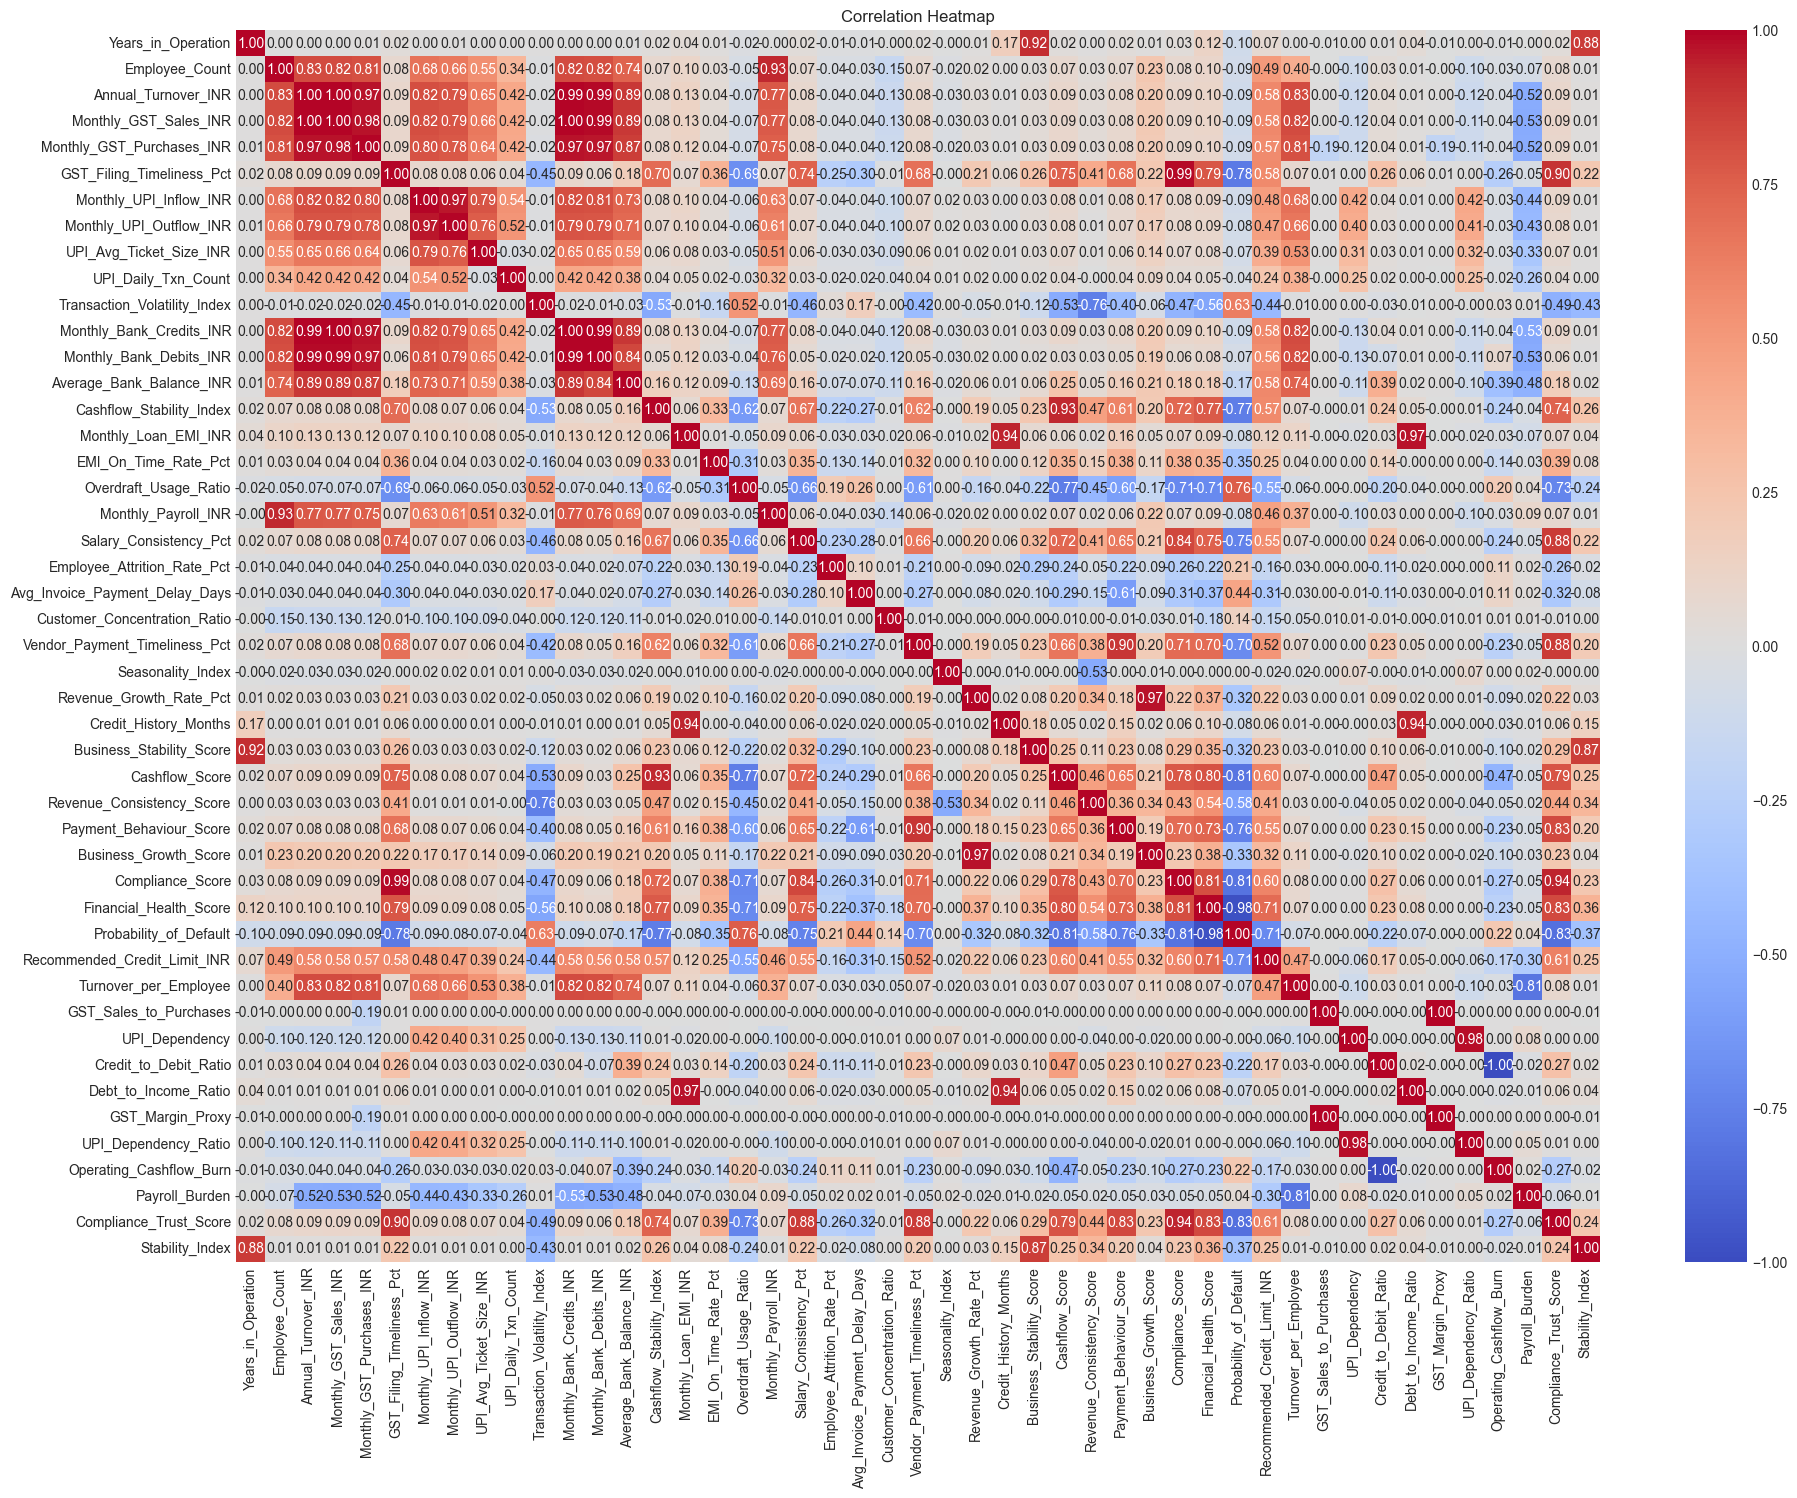

In [15]:
# Select a subset of important numerical features for correlation
selected_features = df.select_dtypes(include=['number']).columns.tolist()

corr_matrix = df[selected_features].corr(method='spearman')

plt.figure(figsize=(22, 16))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Heatmap')

## Categorical Correlation (Cramer's V)

For categorical variables, standard Pearson correlation does not apply. Instead, we use **Cramer's V**, which is based on the Chi-Square statistic. It ranges from 0 (no association) to 1 (perfect association).

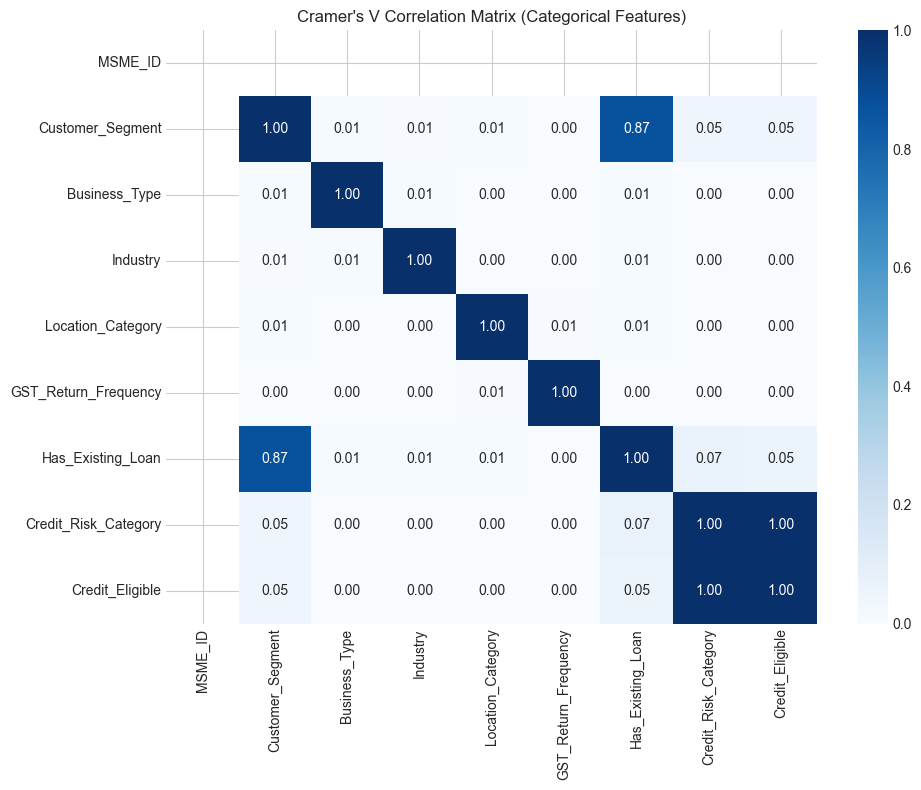

In [ ]:
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = ss.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# Select categorical columns
cat_cols = df.select_dtypes(include=['object']).columns

# Compute Cramer's V matrix
cramers_matrix = pd.DataFrame(np.zeros((len(cat_cols), len(cat_cols))), index=cat_cols, columns=cat_cols)
for col1 in cat_cols:
    for col2 in cat_cols:
        cramers_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])

# Plot the matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cramers_matrix, annot=True, cmap='Blues', fmt='.2f', vmin=0, vmax=1)
plt.title("Cramer's V Correlation Matrix (Categorical Features)")
plt.tight_layout()
plt.show()

## 4. Multicollinearity Check (VIF)
Variance Inflation Factor (VIF) is used to detect multicollinearity. A VIF > 10 indicates high multicollinearity.

In [9]:
# Calculate VIF for independent continuous variables
vif_features = ['Years_in_Operation', 'Employee_Count', 'Annual_Turnover_INR', 
                'Monthly_GST_Sales_INR', 'Monthly_GST_Purchases_INR', 
                'Monthly_UPI_Inflow_INR', 'Average_Bank_Balance_INR',
                'Turnover_per_Employee', 'GST_Sales_to_Purchases']

# Drop rows with infinity/NaNs created during division just in case
X_vif = df[vif_features].replace([np.inf, -np.inf], np.nan).dropna()

# Add constant for VIF calculation
X_vif_const = sm.add_constant(X_vif)

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif_const.values, i) for i in range(X_vif_const.shape[1])]

vif_data = vif_data[vif_data['Feature'] != 'const'].sort_values(by='VIF', ascending=False)


## 5. Heteroscedasticity Check
We will fit a simple OLS regression (e.g., predicting Financial_Health_Score based on Turnover and GST Sales) and plot the residuals against fitted values to check for constant variance (homoscedasticity).

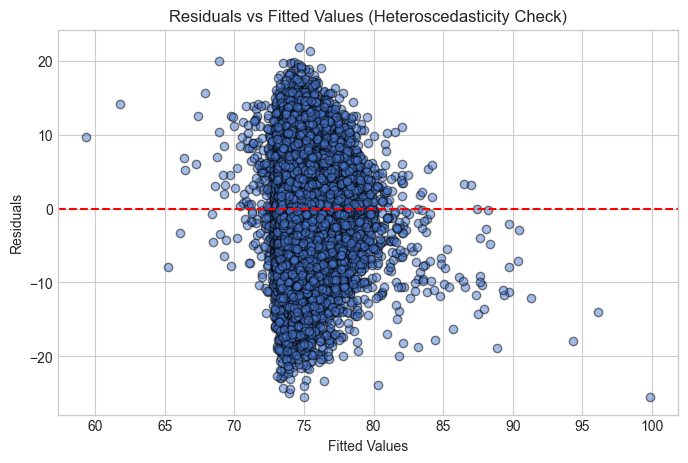

In [10]:
# Prepare data for OLS
X_het = X_vif_const # Includes constant
# Align target with features
y_het = df.loc[X_vif.index, 'Financial_Health_Score']

# Fit OLS model
ols_model = sm.OLS(y_het, X_het).fit()

# Get fitted values and residuals
fitted_vals = ols_model.fittedvalues
residuals = ols_model.resid

# Plot Residuals vs Fitted Values
plt.figure(figsize=(8, 5))
plt.scatter(fitted_vals, residuals, alpha=0.5, edgecolor='k')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values (Heteroscedasticity Check)')
plt.show()

# Interpretation: If the spread of residuals forms a cone or funnel shape, heteroscedasticity is present.


## Feature Engineering: Interaction Features

Based on alternative data such as GST, UPI, and Banking, we engineer powerful financial ratios.

In [11]:
def add_interaction_features(df_input):
    df_new = df_input.copy()
    
    # 1. Debt-to-Income (DTI) Proxy
    df_new['Debt_to_Income_Ratio'] = df_new['Monthly_Loan_EMI_INR'] / (df_new['Monthly_Bank_Credits_INR'] + 1)
    
    # 2. GST Value Addition Margin
    df_new['GST_Margin_Proxy'] = (df_new['Monthly_GST_Sales_INR'] - df_new['Monthly_GST_Purchases_INR']) / (df_new['Monthly_GST_Sales_INR'] + 1)
    
    # 3. Digital Adoption / UPI Dependency Ratio
    df_new['UPI_Dependency_Ratio'] = (df_new['Monthly_UPI_Inflow_INR'] * 12) / (df_new['Annual_Turnover_INR'] + 1)
    
    # 4. Operating Cashflow Burn
    df_new['Operating_Cashflow_Burn'] = df_new['Monthly_Bank_Debits_INR'] / (df_new['Monthly_Bank_Credits_INR'] + 1)
    
    # 5. Payroll Burden
    df_new['Payroll_Burden'] = df_new['Monthly_Payroll_INR'] / (df_new['Monthly_Bank_Credits_INR'] + 1)
    
    # 6. Overall Compliance/Trust Score
    df_new['Compliance_Trust_Score'] = (df_new['GST_Filing_Timeliness_Pct'] + df_new['Vendor_Payment_Timeliness_Pct'] + df_new['Salary_Consistency_Pct']) / 3
    
    # 7. Experience vs. Volatility
    df_new['Stability_Index'] = df_new['Years_in_Operation'] / (df_new['Transaction_Volatility_Index'] + 0.01)
    
    return df_new

df = add_interaction_features(df)
print("Interaction features added successfully. New shape:", df.shape)
df[['Debt_to_Income_Ratio', 'GST_Margin_Proxy', 'UPI_Dependency_Ratio', 'Operating_Cashflow_Burn']].head()

Interaction features added successfully. New shape: (50000, 56)


,Debt_to_Income_Ratio,GST_Margin_Proxy,UPI_Dependency_Ratio,Operating_Cashflow_Burn
0,0.000000,0.312573,0.371634,0.940666
1,0.332582,0.502787,0.410695,0.854488
2,0.000000,0.263009,0.236791,0.641122
3,0.000000,0.100842,0.435624,0.897432
4,0.000000,0.380721,0.771962,0.775171


## Feature Importance Evaluation (Original vs. New Interaction Features)

To check how "good" our newly created interaction features are compared to the original raw values, we can train a quick XGBoost model and extract the **Feature Importances** (weight). If our new ratios score higher than the base columns they were built from, we know the feature engineering was successful!

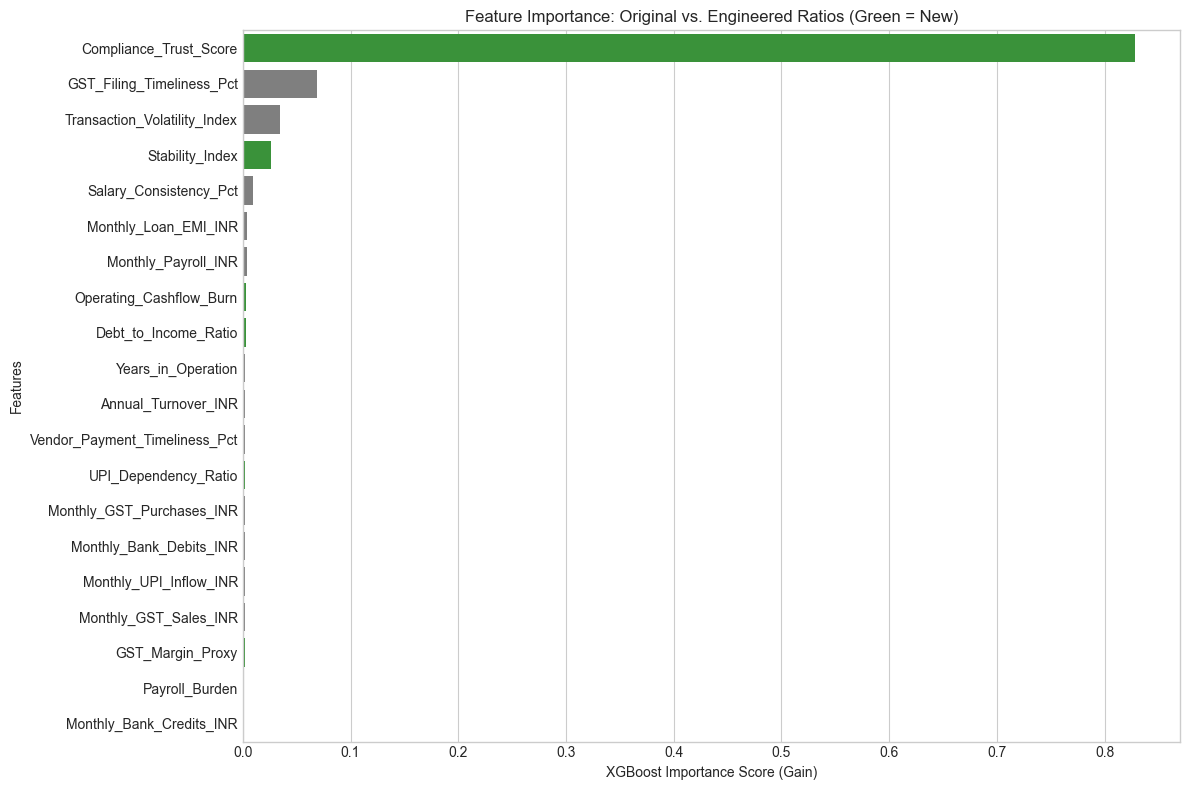

In [18]:
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

# List of the original raw features we used to build our ratios
original_features = [
    'Monthly_Loan_EMI_INR', 'Monthly_Bank_Credits_INR',
    'Monthly_GST_Sales_INR', 'Monthly_GST_Purchases_INR',
    'Monthly_UPI_Inflow_INR', 'Annual_Turnover_INR',
    'Monthly_Bank_Debits_INR', 'Monthly_Payroll_INR',
    'GST_Filing_Timeliness_Pct', 'Vendor_Payment_Timeliness_Pct', 'Salary_Consistency_Pct',
    'Years_in_Operation', 'Transaction_Volatility_Index'
]

# List of the new engineered features
new_features = [
    'Debt_to_Income_Ratio', 'GST_Margin_Proxy', 'UPI_Dependency_Ratio',
    'Operating_Cashflow_Burn', 'Payroll_Burden', 'Compliance_Trust_Score', 'Stability_Index'
]

evaluation_features = original_features + new_features

# Prepare data for a quick ML check (drop NaNs for simplicity in this quick test)
eval_df = df[evaluation_features + ['Financial_Health_Score']].dropna()
X_eval = eval_df[evaluation_features]
y_eval = eval_df['Financial_Health_Score']

# Train a quick XGBoost Regressor
eval_model = xgb.XGBRegressor(n_estimators=50, max_depth=4, random_state=42)
eval_model.fit(X_eval, y_eval)

# Extract and sort Feature Importances
importances = pd.Series(eval_model.feature_importances_, index=X_eval.columns).sort_values(ascending=False)

# Plotting
plt.figure(figsize=(12, 8))
# Color code: Green for new features, Gray for original
colors = ['#2ca02c' if feat in new_features else '#7f7f7f' for feat in importances.index]
sns.barplot(x=importances.values, y=importances.index, palette=colors)
plt.title('Feature Importance: Original vs. Engineered Ratios (Green = New)')
plt.xlabel('XGBoost Importance Score (Gain)')
plt.ylabel('Features')
plt.tight_layout()
plt.show()